# Machine Learning — Notebook 11
## Extracción de Features: Imágenes y Audio

Usamos una imagen real y una grabación real.  
Cambia las rutas en la celda de configuración para usar tus propios archivos.

| Dominio | Features extraídos |
|---|---|
| **Imagen** | Brillo, Histograma de color, FFT 2D, GLCM (textura), Entropía, Forma |
| **Audio** | Energía, ZCR, Espectro (FFT), MFCC |

In [12]:
!pip3 install scikit-image librosa soundfile --quiet --break-system-packages

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import librosa
import librosa.display
from PIL import Image
from skimage.feature import graycomatrix, graycoprops
from skimage.measure import shannon_entropy, label, regionprops
from skimage.filters import threshold_otsu
import warnings; warnings.filterwarnings('ignore')

# ── Rutas ─────────────────────────────────────────────────────────
IMAGE_PATH = "habichuelas.jpg"      # cambia por tu imagen
AUDIO_PATH = "mollyroselee-falling-tree-ai-generated-431321.mp3"    # cambia por tu audio
# ──────────────────────────────────────────────────────────────────
print('Listo.')

Listo.


---
## PARTE 1 — Imagen

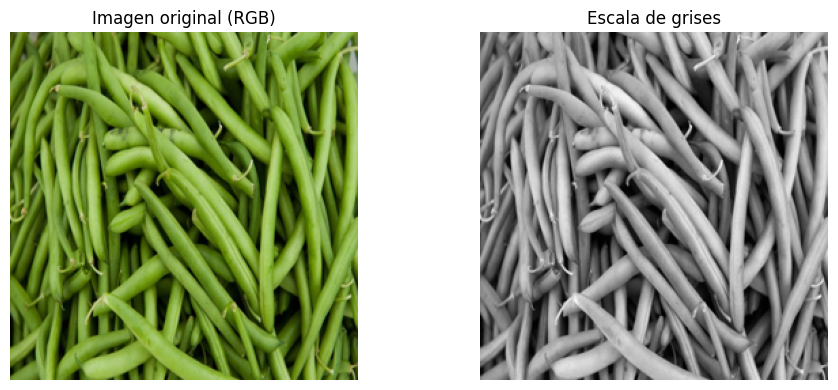

In [14]:
# Cargar y mostrar
img  = np.array(Image.open(IMAGE_PATH).resize((256, 256)))
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img)
axes[0].set_title('Imagen original (RGB)')
axes[0].axis('off')
axes[1].imshow(gray, cmap='gray')
axes[1].set_title('Escala de grises')
axes[1].axis('off')
plt.tight_layout()
plt.show()

Brillo medio : 110.42  (0=negro, 255=blanco)
Desviacion   : 49.08


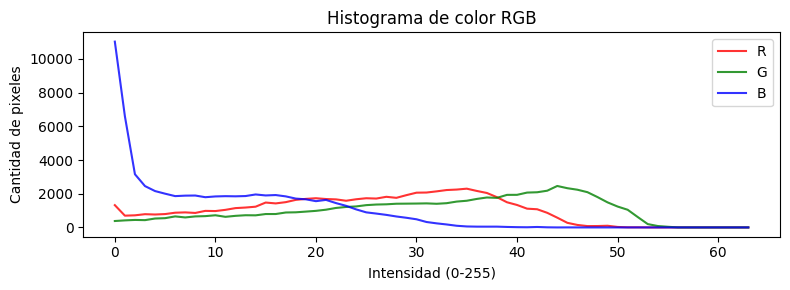

In [15]:
# ── 1. BRILLO ────────────────────────────────────────────────────
brillo_medio = gray.mean()
brillo_std   = gray.std()
print(f'Brillo medio : {brillo_medio:.2f}  (0=negro, 255=blanco)')
print(f'Desviacion   : {brillo_std:.2f}')

# ── 2. HISTOGRAMA DE COLOR ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3))
for canal, color, nombre in zip(range(3), ['red','green','blue'], ['R','G','B']):
    hist = np.histogram(img[:,:,canal], bins=64, range=(0,256))[0]
    ax.plot(hist, color=color, label=nombre, alpha=0.8)
ax.set_xlabel('Intensidad (0-255)')
ax.set_ylabel('Cantidad de pixeles')
ax.set_title('Histograma de color RGB')
ax.legend()
plt.tight_layout()
plt.show()

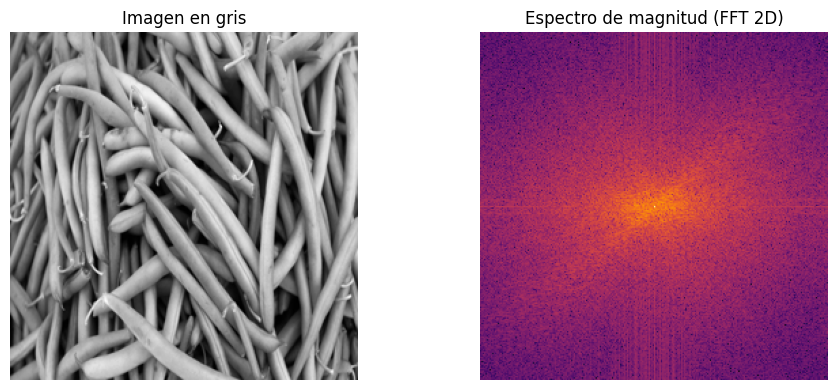

Energia baja frecuencia : 33394.0
Energia alta frecuencia : 2336.6
Ratio alta/baja         : 0.070  (mayor = mas textura/detalle)


In [16]:
# ── 3. FFT 2D (Transformada de Fourier) ──────────────────────────
# Centro del espectro = bajas frecuencias (formas generales)
# Bordes del espectro = altas frecuencias (bordes finos, textura)

fft_shift = np.fft.fftshift(np.fft.fft2(gray.astype(np.float32)))
espectro  = np.log1p(np.abs(fft_shift))

H, W = gray.shape
mask_baja = np.zeros((H, W), dtype=bool)
mask_baja[H//2-H//8:H//2+H//8, W//2-W//8:W//2+W//8] = True
e_baja = np.abs(fft_shift[mask_baja]).mean()
e_alta = np.abs(fft_shift[~mask_baja]).mean()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Imagen en gris')
axes[0].axis('off')
axes[1].imshow(espectro, cmap='inferno')
axes[1].set_title('Espectro de magnitud (FFT 2D)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

print(f'Energia baja frecuencia : {e_baja:.1f}')
print(f'Energia alta frecuencia : {e_alta:.1f}')
print(f'Ratio alta/baja         : {e_alta/e_baja:.3f}  (mayor = mas textura/detalle)')

In [17]:
# ── 4. TEXTURA: GLCM ─────────────────────────────────────────────
# Mide relaciones entre pixeles vecinos
# contrast     -> que tan rugosa es la textura
# energy       -> que tan uniforme/repetitiva es
# homogeneity  -> que tan suave es la transicion entre pixeles
# correlation  -> si hay patrones lineales

glcm = graycomatrix(gray,
                    distances=[1, 2],
                    angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                    levels=256, symmetric=True, normed=True)

contrast    = graycoprops(glcm, 'contrast').mean()
energy      = graycoprops(glcm, 'energy').mean()
homogeneity = graycoprops(glcm, 'homogeneity').mean()
correlation = graycoprops(glcm, 'correlation').mean()

# ── 5. ENTROPIA ───────────────────────────────────────────────────
entropia = shannon_entropy(gray)

print('=== GLCM — Features de Textura ===')
print(f'  contrast    : {contrast:.4f}   (alto = rugosa)')
print(f'  energy      : {energy:.4f}   (alto = uniforme)')
print(f'  homogeneity : {homogeneity:.4f}   (alto = suave)')
print(f'  correlation : {correlation:.4f}   (alto = patrones lineales)')
print(f'  entropia    : {entropia:.4f}   (alto = mas desorden/informacion)')

=== GLCM — Features de Textura ===
  contrast    : 611.8503   (alto = rugosa)
  energy      : 0.0112   (alto = uniforme)
  homogeneity : 0.0996   (alto = suave)
  correlation : 0.8731   (alto = patrones lineales)
  entropia    : 7.5171   (alto = mas desorden/informacion)


=== Caracteristicas de Forma (region mas grande) ===
  Area                  : 35176.0 px2
  Perimetro             : 8926.3 px
  Aspect ratio          : 1.000
  Extent                : 0.537  (area / bounding box)
  Solidity              : 0.541  (area / casco convexo)
  Diametro equivalente  : 211.6 px


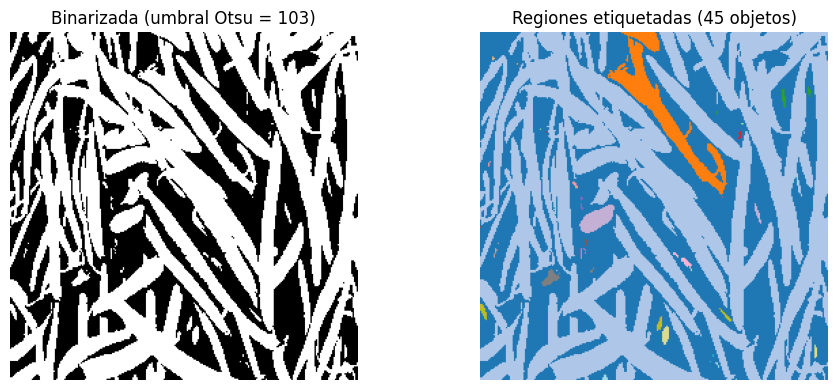

In [18]:
# ── 6. CARACTERISTICAS DE FORMA ──────────────────────────────────
# Binarizar la imagen -> detectar regiones -> medir la mas grande

umbral   = threshold_otsu(gray)
binaria  = gray > umbral
etiqueta = label(binaria)
regiones = regionprops(etiqueta)
region   = max(regiones, key=lambda r: r.area)   # objeto mas grande

minr, minc, maxr, maxc = region.bbox

print('=== Caracteristicas de Forma (region mas grande) ===')
print(f'  Area                  : {region.area} px2')
print(f'  Perimetro             : {region.perimeter:.1f} px')
print(f'  Aspect ratio          : {(maxc-minc)/(maxr-minr+1e-6):.3f}')
print(f'  Extent                : {region.extent:.3f}  (area / bounding box)')
print(f'  Solidity              : {region.solidity:.3f}  (area / casco convexo)')
print(f'  Diametro equivalente  : {region.equivalent_diameter:.1f} px')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(binaria, cmap='gray')
axes[0].set_title(f'Binarizada (umbral Otsu = {umbral:.0f})')
axes[0].axis('off')
axes[1].imshow(etiqueta, cmap='tab20')
axes[1].set_title(f'Regiones etiquetadas ({etiqueta.max()} objetos)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

---
## PARTE 2 — Audio

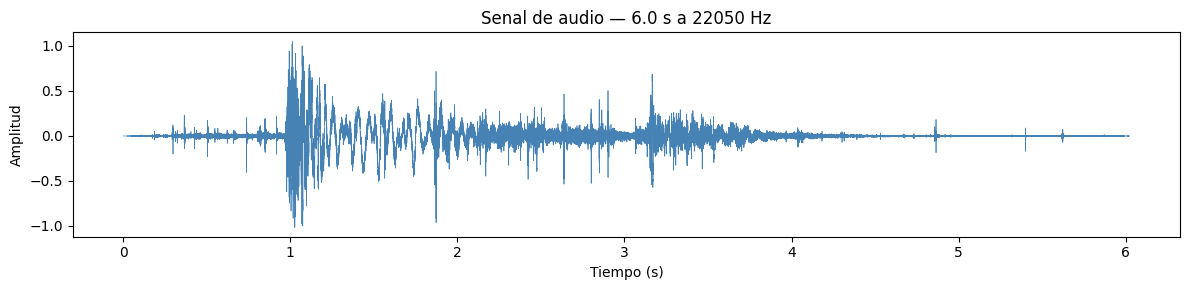

Duracion      : 6.02 s
Muestras      : 132,830
Frec. muestreo: 22050 Hz


In [19]:
# Cargar y mostrar la senal de audio
y_audio, sr = librosa.load(AUDIO_PATH, sr=22050)

t = np.linspace(0, len(y_audio)/sr, len(y_audio))

plt.figure(figsize=(12, 3))
plt.plot(t, y_audio, linewidth=0.5, color='steelblue')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title(f'Senal de audio — {len(y_audio)/sr:.1f} s a {sr} Hz')
plt.tight_layout()
plt.show()

print(f'Duracion      : {len(y_audio)/sr:.2f} s')
print(f'Muestras      : {len(y_audio):,}')
print(f'Frec. muestreo: {sr} Hz')

Energia RMS : 0.09912   (alto = senal mas fuerte)
ZCR media   : 0.19805   (alto = mas ruidoso o percusivo)


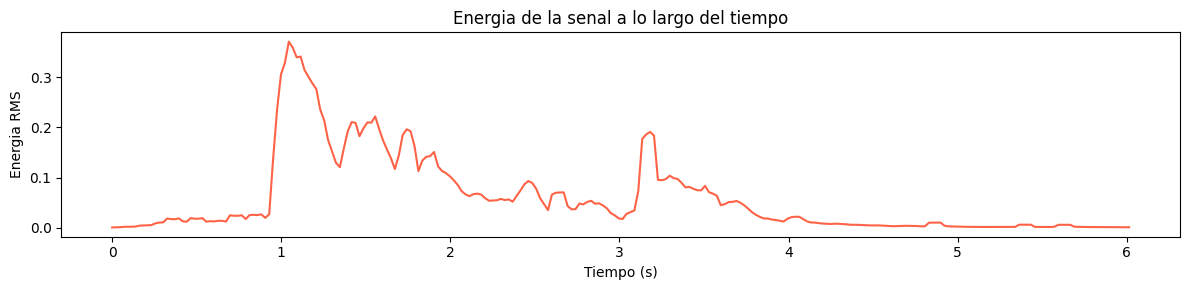

In [20]:
# ── 1. ENERGIA ───────────────────────────────────────────────────
energia_rms = np.sqrt(np.mean(y_audio**2))
print(f'Energia RMS : {energia_rms:.5f}   (alto = senal mas fuerte)')

# ── 2. ZERO-CROSSING RATE (ZCR) ───────────────────────────────────
zcr = librosa.feature.zero_crossing_rate(y_audio).mean()
print(f'ZCR media   : {zcr:.5f}   (alto = mas ruidoso o percusivo)')

# Energia por frames
frame_energy = librosa.feature.rms(y=y_audio)[0]
frames_t = librosa.frames_to_time(np.arange(len(frame_energy)), sr=sr)

plt.figure(figsize=(12, 3))
plt.plot(frames_t, frame_energy, color='tomato')
plt.xlabel('Tiempo (s)')
plt.ylabel('Energia RMS')
plt.title('Energia de la senal a lo largo del tiempo')
plt.tight_layout()
plt.show()

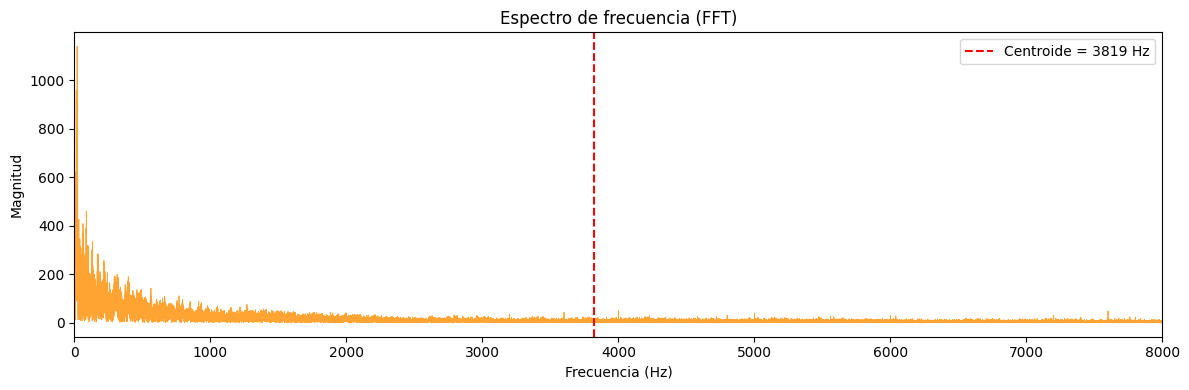

Centroide espectral : 3818.8 Hz   (gravedad del espectro)
Ancho de banda      : 3081.5 Hz   (dispersion alrededor del centroide)


In [21]:
# ── 3. ESPECTRO DE FRECUENCIA (FFT 1D) ───────────────────────────
N = len(y_audio)
magnitud = np.abs(np.fft.fft(y_audio))[:N//2]
freqs    = np.fft.fftfreq(N, d=1/sr)[:N//2]

centroide = librosa.feature.spectral_centroid(y=y_audio, sr=sr).mean()
ancho     = librosa.feature.spectral_bandwidth(y=y_audio, sr=sr).mean()

plt.figure(figsize=(12, 4))
plt.plot(freqs, magnitud, linewidth=0.6, color='darkorange', alpha=0.8)
plt.axvline(centroide, color='red', linewidth=1.5, linestyle='--',
            label=f'Centroide = {centroide:.0f} Hz')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud')
plt.title('Espectro de frecuencia (FFT)')
plt.xlim(0, 8000)
plt.legend()
plt.tight_layout()
plt.show()

print(f'Centroide espectral : {centroide:.1f} Hz   (gravedad del espectro)')
print(f'Ancho de banda      : {ancho:.1f} Hz   (dispersion alrededor del centroide)')

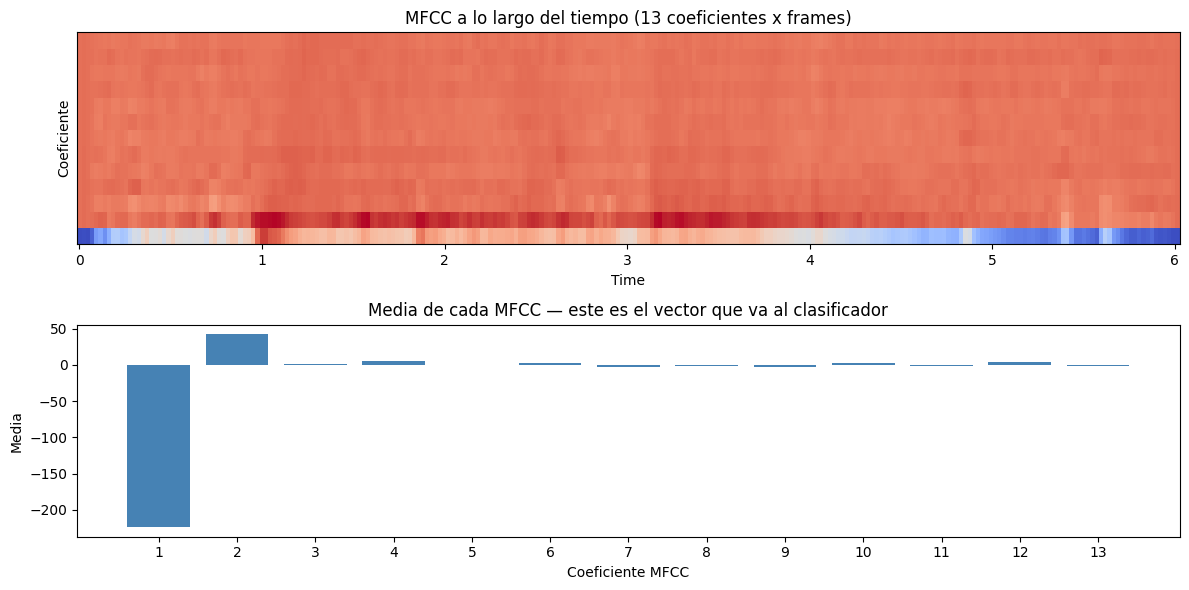

Vector MFCC (media de cada coeficiente):
  MFCC 01: -223.785
  MFCC 02:   41.977
  MFCC 03:    1.811
  MFCC 04:    5.512
  MFCC 05:    0.449
  MFCC 06:    2.489
  MFCC 07:   -2.409
  MFCC 08:   -0.855
  MFCC 09:   -3.133
  MFCC 10:    3.230
  MFCC 11:   -1.460
  MFCC 12:    4.295
  MFCC 13:   -1.220


In [22]:
# ── 4. MFCC ──────────────────────────────────────────────────────
# 13 coeficientes que resumen como el oido humano percibe el sonido.
# Cada coeficiente = una 'dimension' de la textura sonora.

mfccs = librosa.feature.mfcc(y=y_audio, sr=sr, n_mfcc=13)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

librosa.display.specshow(mfccs, sr=sr, x_axis='time',
                         ax=axes[0], cmap='coolwarm')
axes[0].set_title('MFCC a lo largo del tiempo (13 coeficientes x frames)')
axes[0].set_ylabel('Coeficiente')

mfcc_medias = mfccs.mean(axis=1)
axes[1].bar(range(1, 14), mfcc_medias, color='steelblue')
axes[1].set_xlabel('Coeficiente MFCC')
axes[1].set_ylabel('Media')
axes[1].set_title('Media de cada MFCC — este es el vector que va al clasificador')
axes[1].set_xticks(range(1, 14))

plt.tight_layout()
plt.show()

print('Vector MFCC (media de cada coeficiente):')
for i, v in enumerate(mfcc_medias):
    print(f'  MFCC {i+1:02d}: {v:8.3f}')

---
## Funciones de extracción completa

Una función por dominio. Argumento: ruta del archivo. Salida: `pd.DataFrame` con una fila por archivo.

**Features adicionales incluidos:**

| Dominio | Feature nuevo | Qué captura |
|---|---|---|
| Imagen | Estadísticas HSV | Color en espacio perceptual (tono, saturación, brillo) |
| Imagen | Densidad de bordes (Canny) | Cuántos contornos/bordes tiene la imagen |
| Imagen | Varianza del Laplaciano | Nitidez o desenfoque |
| Imagen | LBP (Local Binary Pattern) | Textura local sin parámetros |
| Imagen | Momentos de Hu | Forma invariante a rotación y escala |
| Audio | Chroma (12) | Energía por clase de tono musical |
| Audio | Spectral rolloff | Frecuencia de corte del 85% de la energía |
| Audio | Spectral flatness | Qué tan parecido a ruido blanco es |
| Audio | Spectral contrast (7) | Diferencia picos/valles por sub-banda |
| Audio | Tonnetz (6) | Relaciones tonales y armónicas |
| Audio | MFCC delta (13) | Velocidad de cambio de los MFCC |
| Audio | Tempo | Pulsos por minuto estimados |

In [23]:
from skimage.feature import local_binary_pattern

def extract_image_features(filepath, resize=(256, 256), n_hist_bins=16):
    """
    Extrae features de una imagen.
    Args:
        filepath : ruta al archivo de imagen (jpg, png, etc.)
        resize   : tamanio al que se reescala antes de procesar
        n_hist_bins : bins del histograma de color
    Returns:
        pd.DataFrame con 1 fila y todos los features como columnas
    """
    import pandas as pd
    feats = {'archivo': filepath}

    img  = np.array(Image.open(filepath).resize(resize))
    if img.ndim == 2:                          # imagen en gris -> convertir a RGB
        img = np.stack([img]*3, axis=2)
    if img.shape[2] == 4:                      # RGBA -> RGB
        img = img[:, :, :3]
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # ── BRILLO ──────────────────────────────────────────────────────
    feats['brightness_mean'] = float(gray.mean())
    feats['brightness_std']  = float(gray.std())

    # ── ESTADISTICAS POR CANAL RGB ───────────────────────────────────
    for i, ch in enumerate(['r', 'g', 'b']):
        feats[f'{ch}_mean'] = float(img[:,:,i].mean())
        feats[f'{ch}_std']  = float(img[:,:,i].std())

    # ── HISTOGRAMA DE COLOR (normalizado) ────────────────────────────
    for i, ch in enumerate(['r', 'g', 'b']):
        hist = np.histogram(img[:,:,i], bins=n_hist_bins, range=(0,256))[0]
        hist = hist / (hist.sum() + 1e-8)
        for j, v in enumerate(hist):
            feats[f'hist_{ch}_{j:02d}'] = float(v)

    # ── ESTADISTICAS HSV ─────────────────────────────────────────────
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    for i, ch in enumerate(['hue', 'sat', 'val']):
        feats[f'hsv_{ch}_mean'] = float(hsv[:,:,i].mean())
        feats[f'hsv_{ch}_std']  = float(hsv[:,:,i].std())

    # ── FFT 2D: energia en alta y baja frecuencia ────────────────────
    fft = np.fft.fftshift(np.fft.fft2(gray.astype(np.float32)))
    H, W = gray.shape
    mask = np.zeros((H,W), dtype=bool)
    mask[H//2-H//8:H//2+H//8, W//2-W//8:W//2+W//8] = True
    mag = np.abs(fft)
    feats['fft_energy_low']  = float(mag[mask].mean())
    feats['fft_energy_high'] = float(mag[~mask].mean())
    feats['fft_ratio']       = float(feats['fft_energy_high'] / (feats['fft_energy_low'] + 1e-8))

    # ── GLCM: textura ────────────────────────────────────────────────
    glcm = graycomatrix(gray, distances=[1,2],
                        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=256, symmetric=True, normed=True)
    for prop in ['contrast', 'energy', 'homogeneity', 'correlation']:
        feats[f'glcm_{prop}'] = float(graycoprops(glcm, prop).mean())

    # ── ENTROPIA ─────────────────────────────────────────────────────
    feats['entropy'] = float(shannon_entropy(gray))

    # ── LBP: textura local (Local Binary Pattern) ────────────────────
    lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')
    lbp_hist = np.histogram(lbp, bins=10, range=(0,10))[0]
    lbp_hist = lbp_hist / (lbp_hist.sum() + 1e-8)
    for j, v in enumerate(lbp_hist):
        feats[f'lbp_{j:02d}'] = float(v)

    # ── DENSIDAD DE BORDES (Canny) ────────────────────────────────────
    bordes = cv2.Canny(gray, 50, 150)
    feats['edge_density'] = float(bordes.sum() / (255 * gray.size))

    # ── VARIANZA DEL LAPLACIANO (nitidez) ─────────────────────────────
    feats['laplacian_var'] = float(cv2.Laplacian(gray, cv2.CV_64F).var())

    # ── MOMENTOS DE HU (forma, invariantes) ──────────────────────────
    thresh = threshold_otsu(gray)
    binary = (gray > thresh).astype(np.uint8) * 255
    moments = cv2.moments(binary)
    hu = cv2.HuMoments(moments).flatten()
    for i, v in enumerate(hu):
        feats[f'hu_{i+1}'] = float(-np.sign(v) * np.log10(abs(v) + 1e-10))

    # ── FORMA: region principal ───────────────────────────────────────
    labeled  = label(gray > thresh)
    regiones = regionprops(labeled)
    if regiones:
        region = max(regiones, key=lambda r: r.area)
        minr, minc, maxr, maxc = region.bbox
        feats['shape_area']       = float(region.area)
        feats['shape_perimeter']  = float(region.perimeter)
        feats['shape_aspect']     = float((maxc-minc) / (maxr-minr+1e-6))
        feats['shape_extent']     = float(region.extent)
        feats['shape_solidity']   = float(region.solidity)
        feats['shape_eq_diam']    = float(region.equivalent_diameter)

    return pd.DataFrame([feats])


# Demo
df_img = extract_image_features(IMAGE_PATH)
print(f'Features de imagen: {df_img.shape[1]} columnas')

# Mostrar solo los no-histograma para no saturar
cols_vis = [c for c in df_img.columns if not c.startswith('hist_') and not c.startswith('lbp_')]
df_img[cols_vis]

Features de imagen: 96 columnas


,archivo,brightness_mean,brightness_std,r_mean,r_std,g_mean,g_std,b_mean,b_std,hsv_hue_mean,...,hu_4,hu_5,hu_6,hu_7,shape_area,shape_perimeter,shape_aspect,shape_extent,shape_solidity,shape_eq_diam
0,habichuelas.jpg,110.420135,49.084198,99.739517,46.856373,129.151108,53.605758,41.975601,36.716651,41.101715,...,9.989485,10.0,10.0,10.0,35176.0,8926.322795,1.0,0.536743,0.54087,211.630513


In [24]:
def extract_audio_features(filepath, sr=22050, n_mfcc=13):
    """
    Extrae features de un archivo de audio.
    Args:
        filepath : ruta al archivo de audio (mp3, wav, ogg, etc.)
        sr       : frecuencia de muestreo objetivo
        n_mfcc   : numero de coeficientes MFCC
    Returns:
        pd.DataFrame con 1 fila y todos los features como columnas
    """
    import pandas as pd
    feats = {'archivo': filepath}

    y, sr = librosa.load(filepath, sr=sr)

    # ── ENERGIA ──────────────────────────────────────────────────────
    feats['energy_rms']  = float(np.sqrt(np.mean(y**2)))
    feats['energy_mean'] = float(np.mean(y**2))

    # ── ZERO-CROSSING RATE ───────────────────────────────────────────
    feats['zcr_mean'] = float(librosa.feature.zero_crossing_rate(y).mean())
    feats['zcr_std']  = float(librosa.feature.zero_crossing_rate(y).std())

    # ── ESPECTRO: centroide, ancho de banda, rolloff, flatness ───────
    feats['spec_centroid']  = float(librosa.feature.spectral_centroid(y=y, sr=sr).mean())
    feats['spec_bandwidth'] = float(librosa.feature.spectral_bandwidth(y=y, sr=sr).mean())
    feats['spec_rolloff']   = float(librosa.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85).mean())
    feats['spec_flatness']  = float(librosa.feature.spectral_flatness(y=y).mean())

    # ── SPECTRAL CONTRAST (7 sub-bandas) ─────────────────────────────
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr, n_bands=6)
    for i in range(contrast.shape[0]):
        feats[f'contrast_{i:02d}'] = float(contrast[i].mean())

    # ── CHROMA (12 clases de tono) ────────────────────────────────────
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    for i in range(12):
        feats[f'chroma_{i:02d}'] = float(chroma[i].mean())

    # ── TONNETZ (relaciones armonicas, 6 features) ───────────────────
    try:
        harmonic = librosa.effects.harmonic(y)
        tonnetz  = librosa.feature.tonnetz(y=harmonic, sr=sr)
        for i in range(6):
            feats[f'tonnetz_{i:02d}'] = float(tonnetz[i].mean())
    except Exception:
        for i in range(6):
            feats[f'tonnetz_{i:02d}'] = 0.0

    # ── MFCC (media y std de 13 coeficientes) ────────────────────────
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    for i in range(n_mfcc):
        feats[f'mfcc_{i+1:02d}_mean'] = float(mfccs[i].mean())
        feats[f'mfcc_{i+1:02d}_std']  = float(mfccs[i].std())

    # ── MFCC DELTA (velocidad de cambio) ─────────────────────────────
    delta = librosa.feature.delta(mfccs)
    for i in range(n_mfcc):
        feats[f'mfcc_delta_{i+1:02d}'] = float(delta[i].mean())

    # ── TEMPO (pulsos por minuto) ─────────────────────────────────────
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    feats['tempo'] = float(tempo)

    return pd.DataFrame([feats])


# Demo
df_aud = extract_audio_features(AUDIO_PATH)
print(f'Features de audio: {df_aud.shape[1]} columnas')

# Mostrar solo los no-MFCC/chroma para no saturar
cols_vis = [c for c in df_aud.columns
            if not c.startswith('mfcc_') and not c.startswith('chroma_')
            and not c.startswith('contrast_') and not c.startswith('tonnetz_')]
df_aud[cols_vis]

Features de audio: 74 columnas


,archivo,energy_rms,energy_mean,zcr_mean,zcr_std,spec_centroid,spec_bandwidth,spec_rolloff,spec_flatness,tempo
0,mollyroselee-falling-tree-ai-generated-431321.mp3,0.099118,0.009824,0.198053,0.107087,3818.838133,3081.506717,7673.646804,0.150138,112.347147


---
## Ejercicios

### Ejercicio 1
Cambia `IMAGE_PATH` por otra imagen de tu proyecto. Compara el `contrast` del GLCM y la `entropia` entre dos clases. ¿Cuál feature las separa mejor?

### Ejercicio 2
Cambia `AUDIO_PATH` por una grabacion de otra clase. Compara `ZCR`, `centroide` y `MFCC_01`. ¿Cuál feature separa mejor las dos clases?

### Ejercicio 3
Extrae los features de 10 imagenes (5 de cada clase) y arma un `pd.DataFrame`. Entrena un `RandomForestClassifier` y mira cual feature tiene mayor `feature_importances_`.